In [3]:
!pip install xgboost


In [4]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")


In [5]:
df = pd.read_csv(
    "hf://datasets/zefang-liu/phishing-email-dataset/Phishing_Email.csv"
)

df.head()


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [6]:
df.info()
df.isnull().sum()
df.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [7]:
df.rename(columns={
    'Email Text': 'email_text',
    'Email Type': 'label'
}, inplace=True)

df.head()


,Unnamed: 0,email_text,label
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [8]:
df['label_binary'] = df['label'].map({
    'Phishing Email': 1,
    'Safe Email': 0
})

df['label_binary'].value_counts()


label_binary
0    11322
1     7312
Name: count, dtype: int64

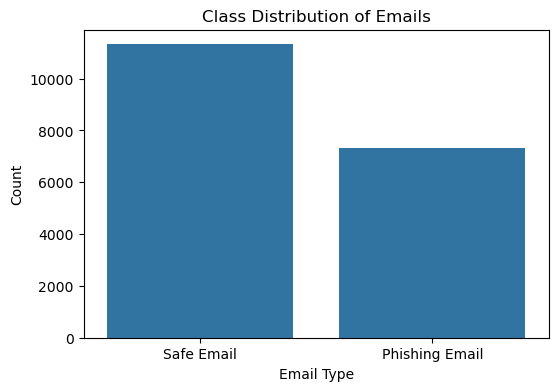

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution of Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()


In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text)
    return text


In [11]:
df['clean_email'] = df['email_text'].apply(clean_text)


In [12]:
X = df['clean_email']
y = df['label_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [14]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_tfidf, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
y_pred = xgb_model.predict(X_test_tfidf)
y_prob = xgb_model.predict_proba(X_test_tfidf)[:, 1]


In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9551918433056077

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2265
           1       0.93      0.96      0.94      1462

    accuracy                           0.96      3727
   macro avg       0.95      0.96      0.95      3727
weighted avg       0.96      0.96      0.96      3727



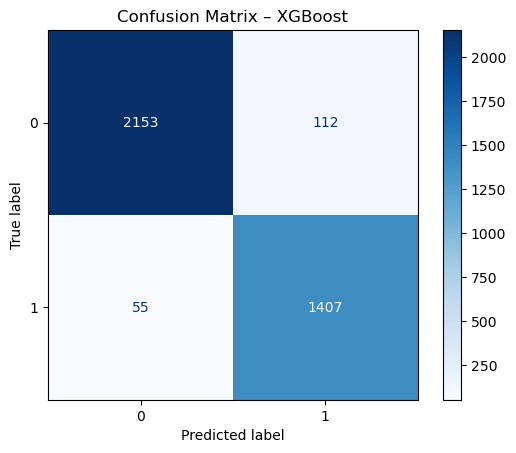

In [17]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – XGBoost")
plt.show()


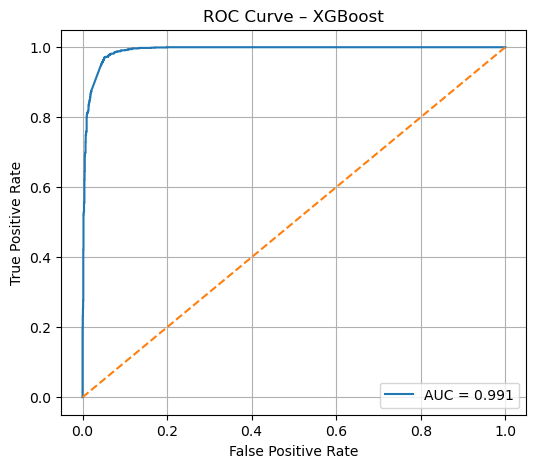

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.grid(True)
plt.show()


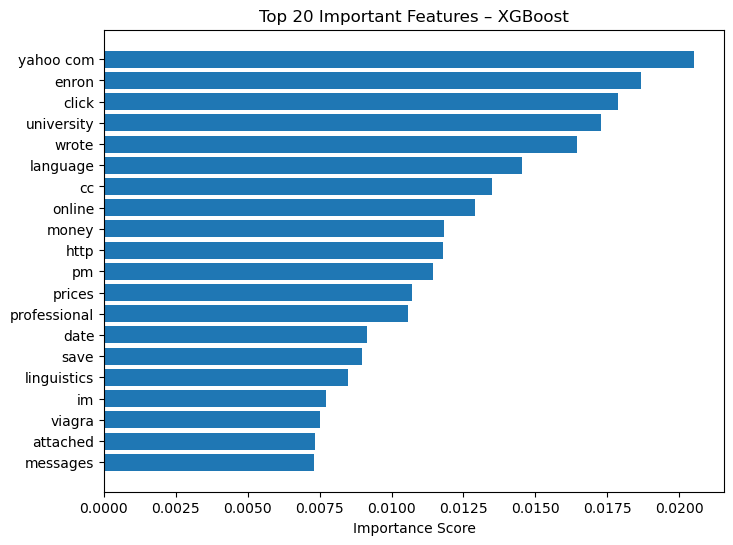

In [19]:
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(
    range(len(indices)),
    importances[indices]
)
plt.yticks(
    range(len(indices)),
    [tfidf.get_feature_names_out()[i] for i in indices]
)
plt.title("Top 20 Important Features – XGBoost")
plt.xlabel("Importance Score")
plt.show()


In [22]:

y_train_pred_xgb = xgb_model.predict(X_train_tfidf)

print("XGBoost - TRAINING DATA\n")
print(classification_report(y_train, y_train_pred_xgb))

print("\nXGBoost - TESTING DATA\n")
print(classification_report(y_test, y_pred))


XGBoost - TRAINING DATA

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      9057
           1       0.95      0.99      0.97      5850

    accuracy                           0.98     14907
   macro avg       0.97      0.98      0.98     14907
weighted avg       0.98      0.98      0.98     14907


XGBoost - TESTING DATA

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2265
           1       0.93      0.96      0.94      1462

    accuracy                           0.96      3727
   macro avg       0.95      0.96      0.95      3727
weighted avg       0.96      0.96      0.96      3727



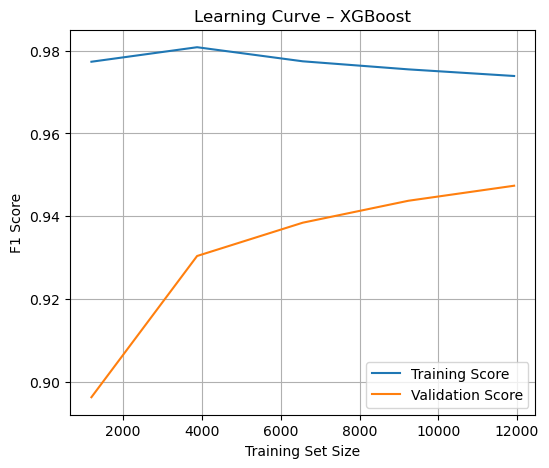

In [23]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
plot_learning_curve(
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='binary:logistic',
        eval_metric='logloss'
    ),
    X_train_tfidf,
    y_train,
    "Learning Curve – XGBoost"
)


In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='f1', n_jobs=-1)

grid_xgb.fit(X_train_tfidf, y_train)

print(f"Best Parameters for XGBoost: {grid_xgb.best_params_}")
best_xgb_model = grid_xgb.best_estimator_

Best Parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 200, 'subsample': 1.0}


In [24]:
y_pred_xgb = best_xgb_model.predict(X_test_tfidf)
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2265
           1       0.93      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.95      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



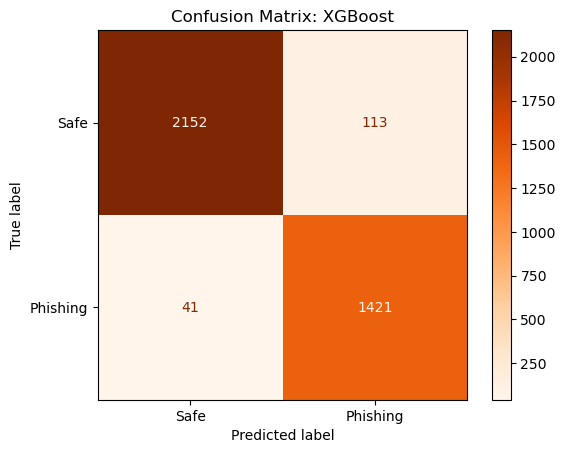

In [25]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Safe', 'Phishing'])
disp_xgb.plot(cmap='Oranges')
plt.title('Confusion Matrix: XGBoost')
plt.show()

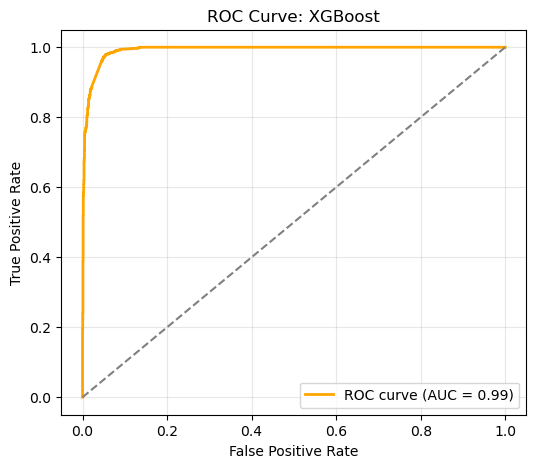

In [26]:
y_prob_xgb = best_xgb_model.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

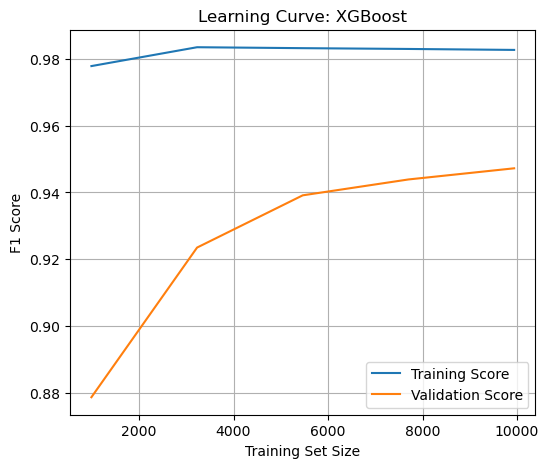

In [27]:
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb_model, X_train_tfidf, y_train, cv=3, scoring='f1', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(6, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve: XGBoost")
plt.legend()
plt.grid(True)
plt.show()

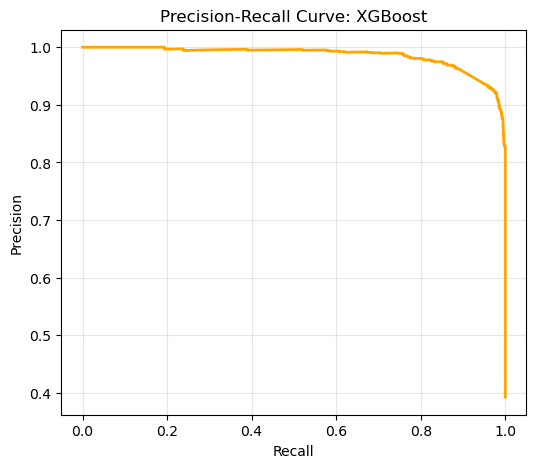

In [29]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='orange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: XGBoost')
plt.grid(alpha=0.3)
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(best_xgb_model, X_train_tfidf, y_train, cv=kf, scoring='accuracy')

print("XGBoost K-Fold Scores:", cv_scores_xgb)
print(f"Mean Accuracy: {cv_scores_xgb.mean():.4f}")
print(f"Standard Deviation: {cv_scores_xgb.std():.4f}")

XGBoost K-Fold Scores: [0.95674044 0.96311201 0.95907414 0.96611875 0.96242872]
Mean Accuracy: 0.9615
Standard Deviation: 0.0033


In [33]:
import joblib
joblib.dump(best_xgb_model, 'phishing_xgboost_model.pkl')

['phishing_xgboost_model.pkl']